# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

In [2]:
df = pd.read_csv("/Users/yaswanth/Downloads/GiveMeSomeCredit/cs-training.csv")

# Structure and shape

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
df.shape

(150000, 12)

# Column classification

In [6]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

# Explanation of columns

### Target column
- SeriousDlq : A serious delinquency refers to a, usually, mortgage or credit account that is 90 days or more past due, indicating a high risk of default and potential legal action like foreclosure or repossession

- SeriousDlqin2yrs = 0 --> Low_risk to process loan.
- SeriousDlqin2yrs = 1 --> High_risk to process loan.


- These 0 or 1 prediction is done based on Important features : "RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'"

### RevolvingUtilizationOfUnsecuredLines --> 
- credit utilization and that are not secured by any property.

#### Examples Included in RevolvingUtilizationOfUnsecuredLines
- Credit Cards: The most common form of revolving credit.
- Personal Lines of Credit (PLOC): Unsecured revolving lines of credit.
- Overdraft Protection Plans: Linked to checking accounts. 
   

### age
- shows the stability of income the customer gets.

### No.of Dependents
- gives us idea, how many members depends on him or on his "Monthly_Income".

### DebtRatio
- Shows us ratio --> How much Monthly debt the customers has/Total Monthly Income.

### These columns for gives us the intuition that how customers Behaviour and discipline in repaying the loans

- NumberOfTime30-59DaysPastDueNotWorse', --> No .of times customers delayes payment in between 30-59days
- 'NumberOfOpenCreditLinesAndLoans',     --> No .of Credit/loans he has.
- 'NumberOfTimes90DaysLate',             --> No.of times the Customers delayed the payment more than 90 days.
- 'NumberRealEstateLoansOrLines',        --> No .of Credit/loans --> Home loans, Mortagages etc.
- 'NumberOfTime60-89DaysPastDueNotWorse',--> No .of times customers delayes payment in between 60-89days

# Data Quality Checks

### Handling Missing data

In [7]:
df.isnull().sum() # to check if there are any missing values.

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

### Observation:
- Missing value found in "MonthlyIncome" and "NumberOfDependents"

In [8]:
df["Income_missing"] = df['MonthlyIncome'].isna().astype(int)

# Keeps History of Missing Values i.e., Creating flags when we think filling sents Risk singnals.

In [9]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0


In [10]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df.groupby("age")["MonthlyIncome"].transform('median'))

# transform --> groupby → process → expand back to original shape.

In [11]:
df["dep_missing"] = df["NumberOfDependents"].isna().astype(int)

# why creating flags for missing values is important?
# when we think the features/columns filling sents risk_signal --> creating flags makes sense(shows previous data)

In [12]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0


In [13]:
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df.groupby("age")["NumberOfDependents"].transform("median"))

#As shown, transform('mean') returns a Series of the same length as the original DataFrame, 
# allowing it to be directly assigned as a given column. 

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         149996 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

### Observation :
- after filling missing values by grouping..i get to know in this risk data set, there are still some missing values, 
- that cant be grouped --> so decide to fill the remaining missing values again

### Why ? 
- 

In [15]:
df[df["MonthlyIncome"].isnull()]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
40007,40008,0,0.064748,107,0,939.0,NaN,9,0,1,0,0.0,1,0
56761,56762,0,0.003469,105,0,2.0,NaN,4,0,0,0,NaN,1,1
105790,105791,0,0.109307,109,0,2141.0,NaN,17,0,1,0,NaN,1,1
138291,138292,0,0.246529,109,0,318.0,NaN,3,0,0,0,NaN,1,1


In [16]:
df.loc[:,"MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
a =df["MonthlyIncome"].unique()

In [17]:
df[df["NumberOfDependents"].isnull()]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
56761,56762,0,0.003469,105,0,2.0,5584.0,4,0,0,0,NaN,1,1
105790,105791,0,0.109307,109,0,2141.0,5584.0,17,0,1,0,NaN,1,1
138291,138292,0,0.246529,109,0,318.0,5584.0,3,0,0,0,NaN,1,1


In [18]:
df.loc[:,"NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         150000 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

### ---------------------------------- Done with Handling Missing Values --------------------------------------

# Handling Duplicates 

In [20]:
df.drop("Unnamed: 0",axis = 1,inplace = True)
df.duplicated().sum()
df[df.duplicated()]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
1669,0,1.0,29,0,0.0,3395.5,0,0,0,0,0.0,1,0
7823,0,1.0,29,0,0.0,3395.5,0,0,0,0,0.0,1,0
7920,0,1.0,22,0,0.0,820.0,1,0,0,0,0.0,0,0
8840,0,1.0,23,0,0.0,820.0,1,0,0,0,0.0,0,0
10869,0,1.0,73,0,0.0,5000.0,2,0,0,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149139,0,0.0,77,0,0.0,4263.0,2,0,0,0,0.0,1,0
149431,0,1.0,25,0,0.0,2250.0,1,0,0,0,0.0,1,1
149472,0,1.0,84,0,0.0,4200.0,1,0,0,0,0.0,1,0
149769,0,1.0,23,98,0.0,1400.0,0,98,0,98,0.0,1,1


In [21]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

0

# Handling Outliers

In [22]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
count,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000,1.493910e+05,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000,149391.000000
mean,0.066999,6.071087,52.306237,0.393886,354.436740,6.439290e+03,8.480892,0.238120,1.022391,0.212503,0.745540,0.195601,0.025624
std,0.250021,250.263672,14.725962,3.852953,2041.843455,1.292248e+04,5.136515,3.826165,1.130196,3.810523,1.107143,0.396664,0.158011
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030132,41.000000,0.000000,0.177441,3.783000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154235,52.000000,0.000000,0.368234,5.584000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.556494,63.000000,0.000000,0.875279,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000,1.000000


<Axes: ylabel='RevolvingUtilizationOfUnsecuredLines'>

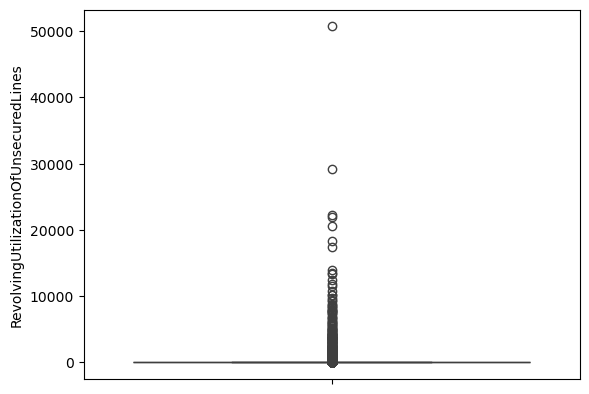

In [23]:
sns.boxplot(df["RevolvingUtilizationOfUnsecuredLines"]) # for one column we check and detect outliers.

In [24]:
# If we want to check the outliers for multiple columns present in the dataset.
# outlier_detection
def outlier_detection(df,col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    L_B = Q1 - 1.5 * IQR
    U_B = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < L_B) | (df[col] > U_B)]

    return outliers



In [25]:
outlier_detection(df,"age")

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing
436,0,0.007000,97,0,3.000000,4222.5,2,0,0,0,0.0,1,1
2922,0,0.005043,99,0,800.000000,6500.0,5,0,0,0,0.0,1,1
7763,0,0.069167,101,0,50.000000,2274.5,2,0,0,0,0.0,1,0
9359,0,0.000000,97,0,0.000000,0.0,3,0,0,0,0.0,0,0
9870,0,0.012737,98,0,0.006503,2152.0,6,0,0,0,0.0,0,0
11854,0,0.000000,98,0,0.000000,2152.0,2,0,0,0,0.0,1,1
12852,0,0.059038,97,0,0.003333,6000.0,3,0,0,0,1.0,0,0
18759,0,0.008464,97,0,8.000000,4222.5,4,0,0,0,0.0,1,1
19884,0,1.000000,103,0,0.000000,1600.0,3,0,0,0,0.0,0,0
24007,0,0.000843,99,0,0.000000,6500.0,4,0,0,0,0.0,1,1


<Axes: ylabel='age'>

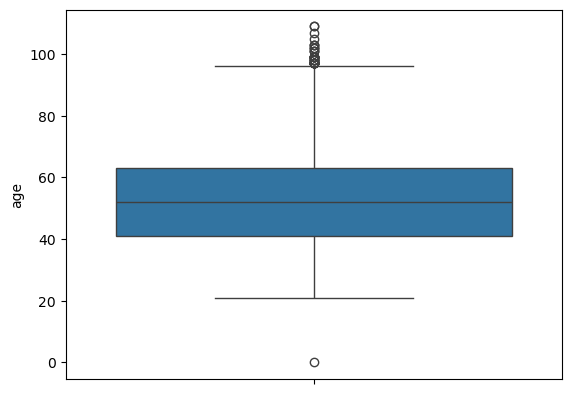

In [26]:
sns.boxplot(df["age"])

In [27]:
# Here We Understand that One column has Outliers, How to showcase all the columns which as outliers.
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'Income_missing', 'dep_missing'],
      dtype='object')

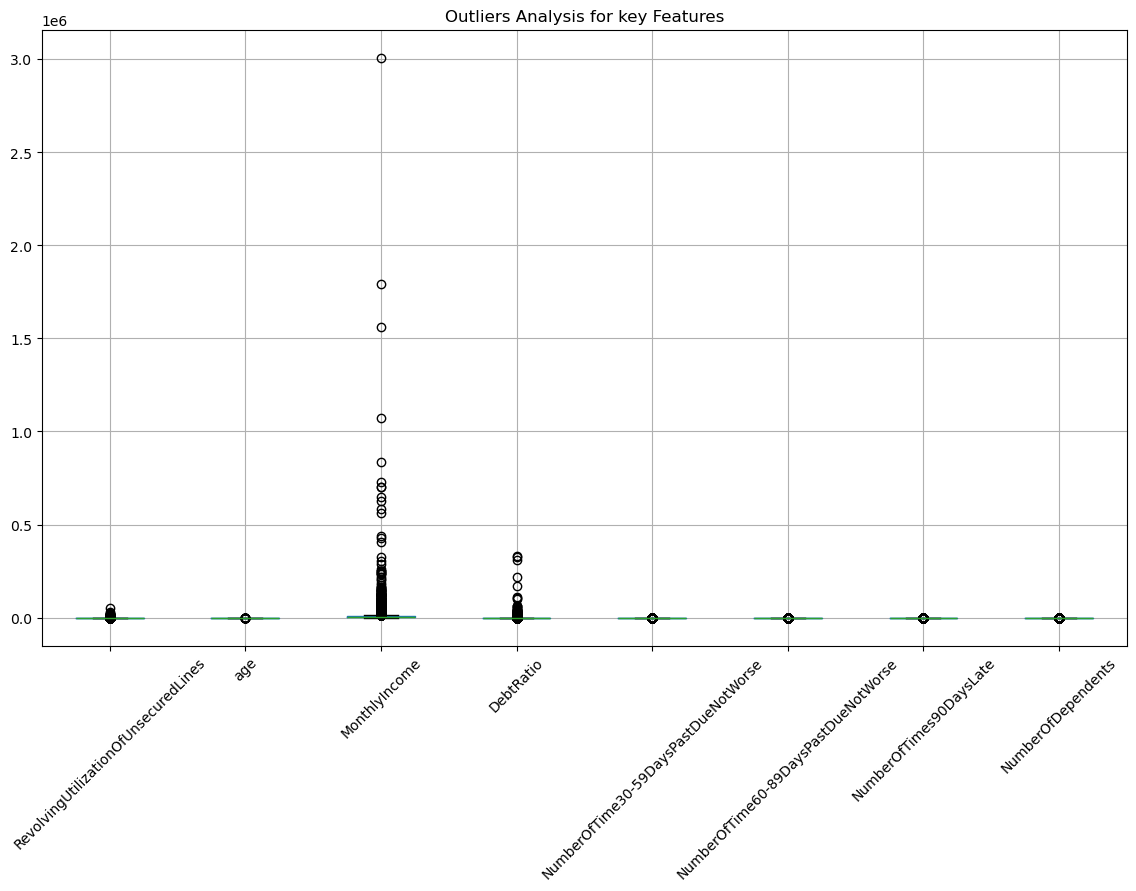

In [28]:

cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'MonthlyIncome',
    'DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfDependents'
]

plt.figure(figsize = (14,8))

df[cols].boxplot(rot = 45)

plt.title("Outliers Analysis for key Features")
plt.show()

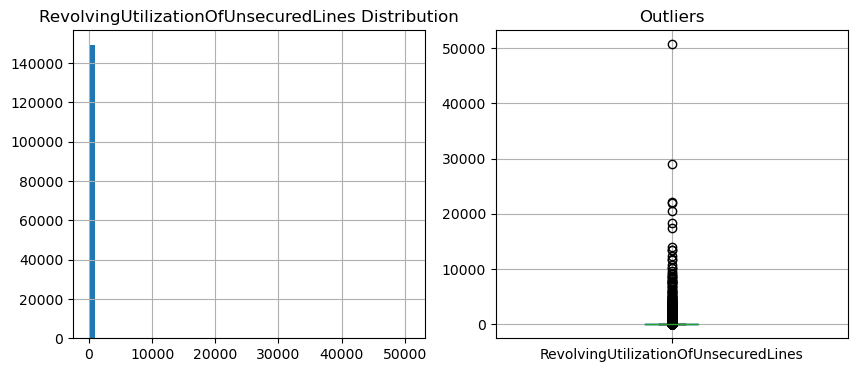

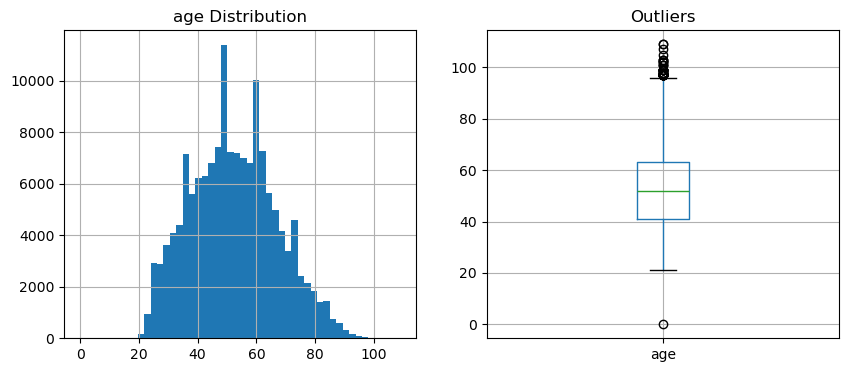

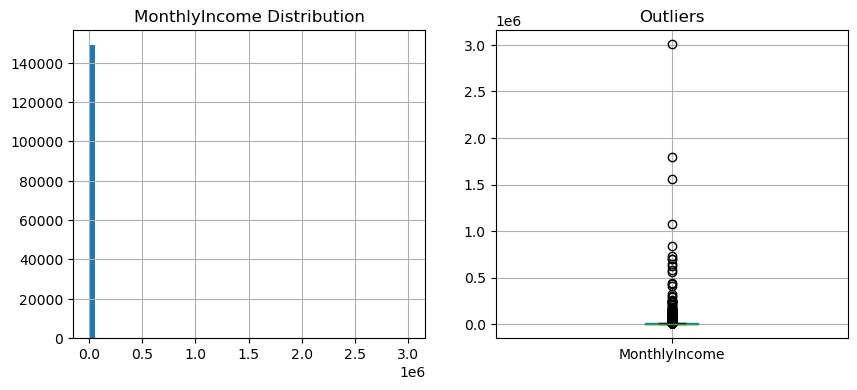

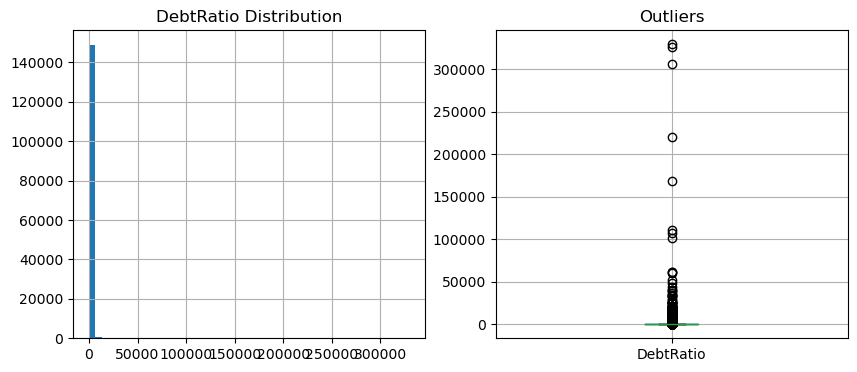

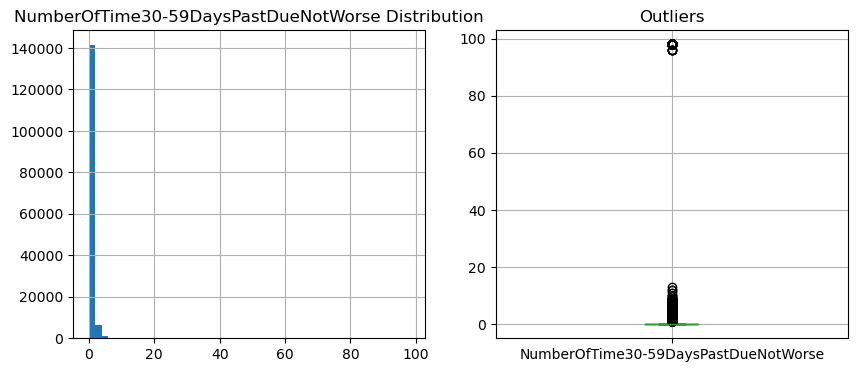

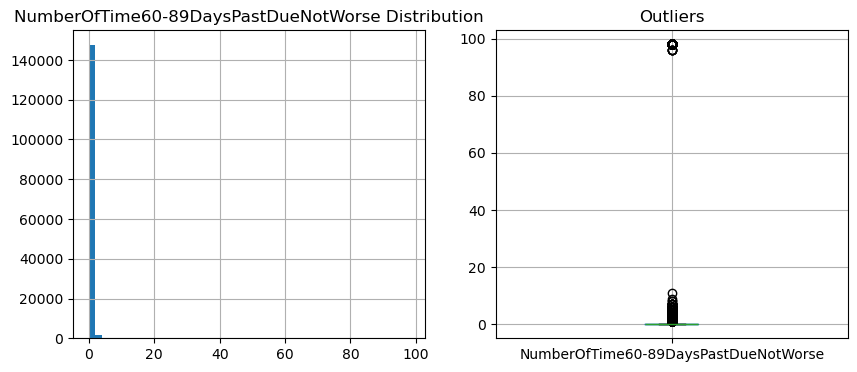

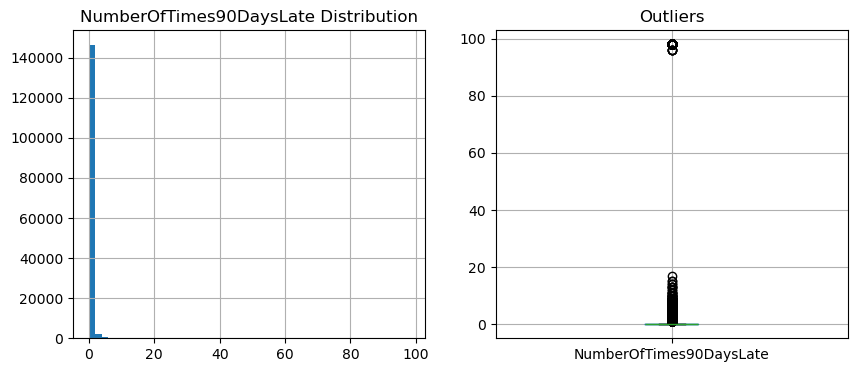

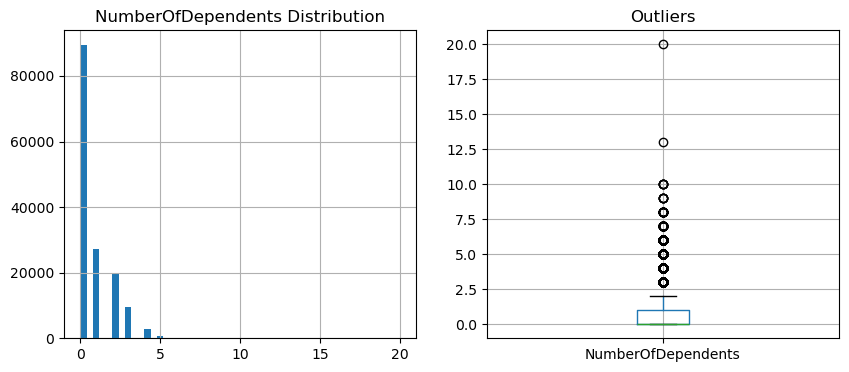

In [29]:
for col in cols:
    
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    
    df[col].hist(ax=ax[0], bins=50)
    ax[0].set_title(f"{col} Distribution")
    
    df.boxplot(column=col, ax=ax[1])
    ax[1].set_title("Outliers")
    
    plt.show()

# Outlier Handling

# Observation : 

- Based on features, we detect outliers and Handled.
# Here my dataset is "Credit risk"
- For Datatypes like this, Outliers would be "High-Risk Profiles", if we drop these considered as model destroying.


# What i did here to treat using techniques
- "Winsorization"
- Log transformation
- Bucketing them
- logical handling.


In [30]:
# Q1 = df["MonthlyIncome"].quantile(0.25)
# Q3 = df["MonthlyIncome"].quantile(0.75)
# IQR = Q3 - Q1
# L_B = Q1 - 1.5 * IQR
# U_B = Q3 + 1.5 * IQR


# df["MonthlyIncome"].clip(L_B,U_B)

In [31]:
def treat_outliers(df,col, method='cap'):
    
    if method == 'cap':
        l_b = df[col].quantile(0.01)
        u_b = df[col].quantile(0.99)
        df[col] = df[col].clip(l_b, u_b)
        
    elif method == 'log':
        df[col] = np.log1p(df[col])
        
    elif method == 'filter':
        df = df[(df[col] >= 18) & (df[col] <= 100)]
        
    return df

In [32]:
df["raw_income"] = df["MonthlyIncome"]
df.head()
df = treat_outliers(df,"MonthlyIncome",'log')
df[df["MonthlyIncome"] == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing,raw_income
14,0,0.019657,76,0,477.0,0.0,6,0,1,0,0.0,0,0,0.0
50,0,0.818978,73,0,3095.0,0.0,9,0,1,1,0.0,0,0,0.0
73,0,0.059669,31,0,3162.0,0.0,11,0,2,0,1.0,0,0,0.0
90,0,0.039388,51,0,15466.0,0.0,7,0,0,0,0.0,0,0,0.0
298,0,0.085152,25,0,1005.0,0.0,5,0,0,0,0.0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149383,0,0.239302,63,0,3153.0,0.0,29,0,1,0,0.0,0,0,0.0
149562,0,0.230799,72,0,430.0,0.0,7,0,0,0,0.0,0,0,0.0
149646,0,0.080084,69,0,1248.0,0.0,8,0,1,0,1.0,0,0,0.0
149673,0,0.132362,82,0,4123.0,0.0,14,0,2,0,0.0,0,0,0.0


In [33]:

df['income_zero_flag'] = (df['MonthlyIncome'] == 0).astype(int)
df.loc[df['MonthlyIncome'] == 0, 'MonthlyIncome'] = np.nan
df['MonthlyIncome'] = df.groupby('age')['MonthlyIncome'].transform('median')

In [34]:
df["raw_debt"] = df["DebtRatio"]
df.loc[:,"DebtRatio"] = treat_outliers(df,"DebtRatio","log")

In [35]:
df = treat_outliers(df,"age","filter")

In [36]:
df.loc[:,"Credit_Utilization"] = pd.cut(df["RevolvingUtilizationOfUnsecuredLines"],bins = [0.0,0.3,0.7,1.0,50708],labels = ["Good","Medium","Risk","High-Risk"],include_lowest = True)

# Alternative way :
# --> df = df.copy() --> after heavy treatment or filtering.

In [37]:
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing,raw_income,income_zero_flag,raw_debt,Credit_Utilization
0,1,0.766127,45,2,0.589442,8.716208,13,0,6,0,2.0,0,0,9120.0,0,0.802982,Risk
1,0,0.957151,40,0,0.115002,8.606119,4,0,0,0,1.0,0,0,2600.0,0,0.121876,Risk
2,0,0.658180,38,1,0.081684,8.566174,2,1,0,0,0.0,0,0,3042.0,0,0.085113,Medium
3,0,0.233810,30,0,0.035415,8.195196,5,0,0,0,0.0,0,0,3300.0,0,0.036050,Good
4,0,0.907239,49,1,0.024620,8.762646,7,0,1,0,0.0,0,0,63588.0,0,0.024926,Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.203048,8.455531,4,0,1,0,0.0,0,0,2100.0,0,0.225131,Good
149996,0,0.299745,44,0,0.540324,8.699681,4,0,1,0,2.0,0,0,5584.0,0,0.716562,Good
149997,0,0.246044,58,0,8.261268,8.754792,18,0,1,0,0.0,1,0,6340.0,0,3870.000000,Good
149998,0,0.000000,30,0,0.000000,8.195196,4,0,0,0,0.0,0,0,5716.0,0,0.000000,Good


<Axes: >

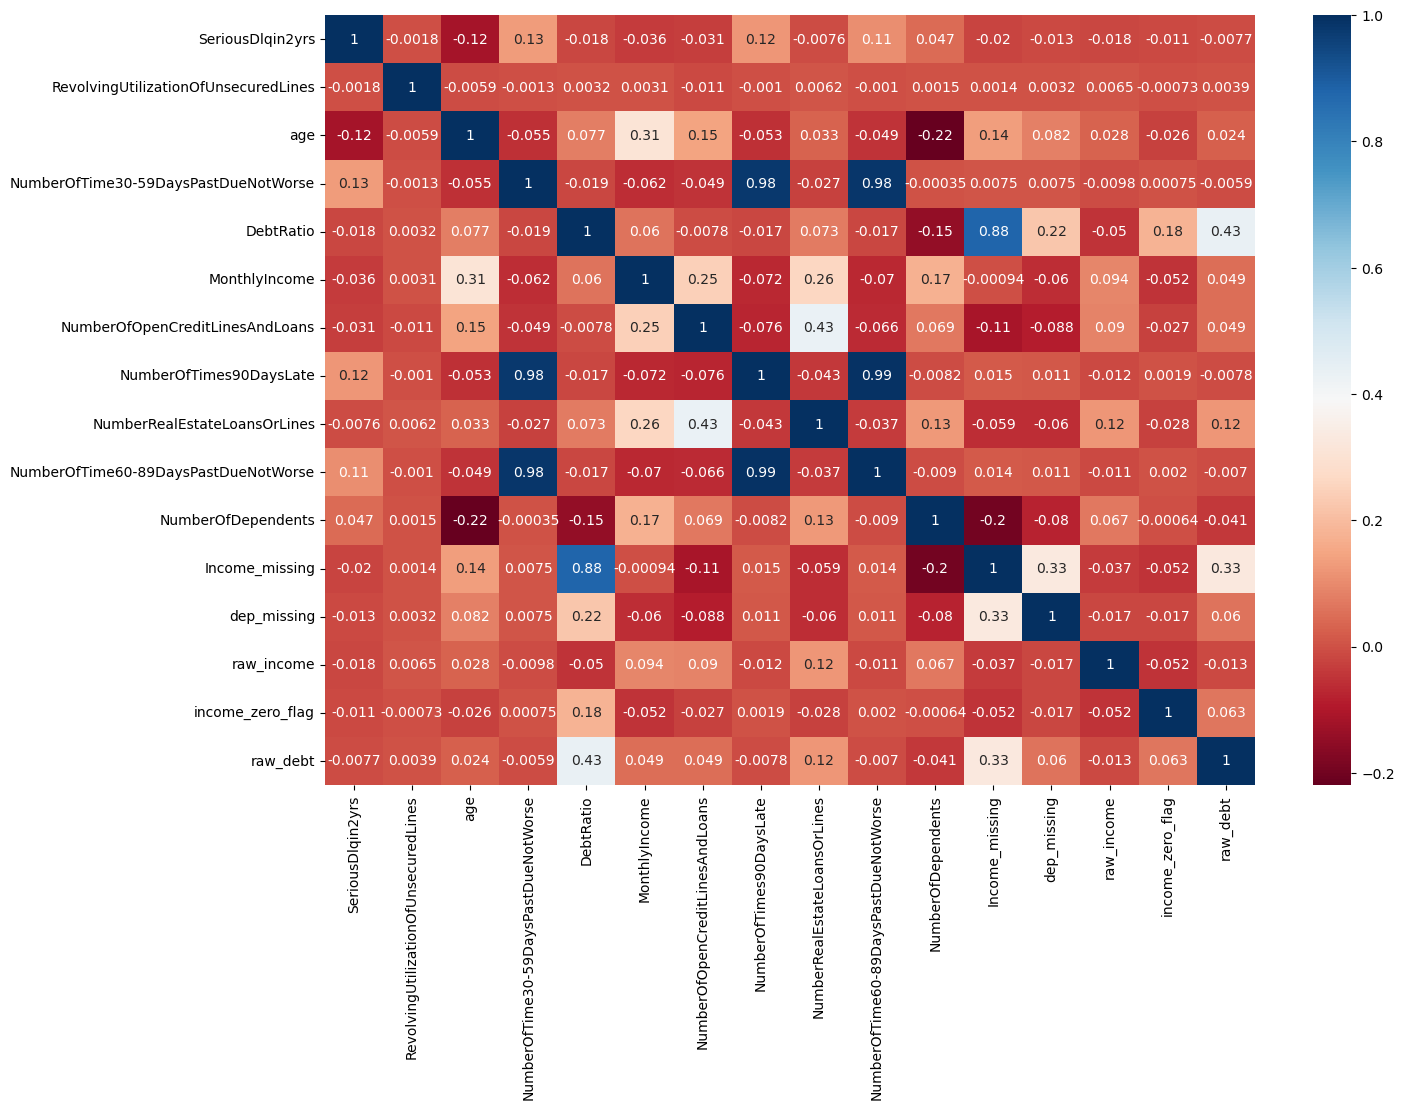

In [38]:
# Correlation
df_num = df.select_dtypes(include = "number").corr()
plt.figure(figsize = (15,10))
sns.heatmap(df_num,annot = True, cmap = "RdBu")

# Univariate Analysis

In [39]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'Income_missing', 'dep_missing', 'raw_income',
       'income_zero_flag', 'raw_debt', 'Credit_Utilization'],
      dtype='object')

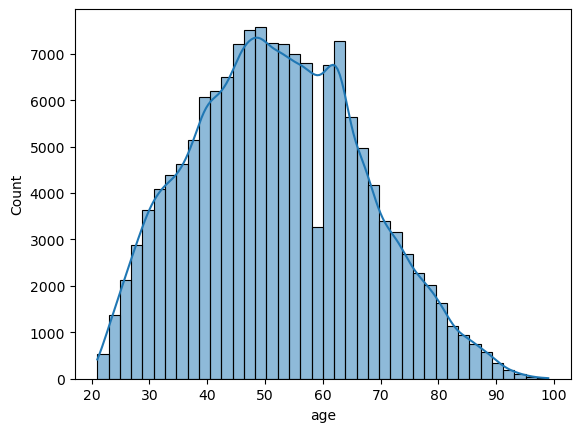

In [40]:
sns.histplot(df["age"],bins = 40,kde = True)
plt.show()

# Observation :
- Distribution is slightly right-skewed.
- Most customers are between 30–55 years.
- Very few <25 and >80.

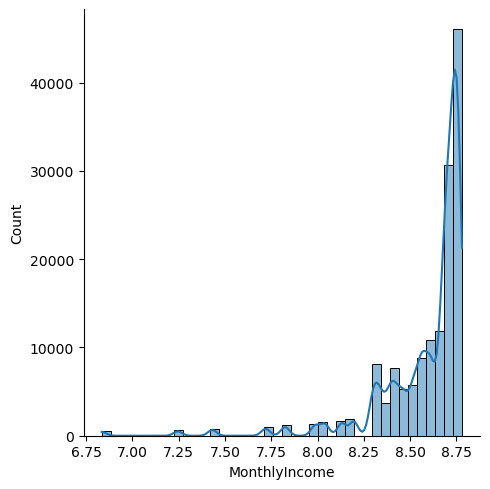

In [41]:
sns.displot(df["MonthlyIncome"],bins = 40,kde = True)
plt.show()


# Observation : 

- Highly right-skewed.
- Long tail even after treatment.
- Median << Mean.
# Meaning
- Majority earn moderate income.
- Few very high earners (important low-risk group).
- Log transform is justified.


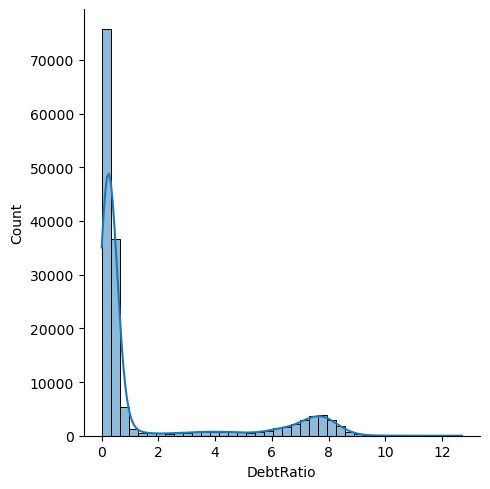

In [42]:
sns.displot(df["DebtRatio"],bins = 40,kde = True)
plt.show()

# Observation :

- Original data was extremely skewed.
- After log transform → smoother curve.
- Still right-skewed.

# Meaning :
- Most customers are moderately leveraged.
- Small group is heavily stressed financially.
- Good predictive feature.

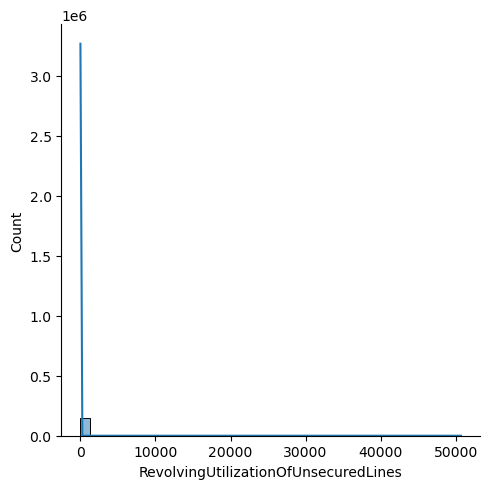

In [43]:
sns.displot(df["RevolvingUtilizationOfUnsecuredLines"],bins = 40,kde = True)
plt.show()

# Observation :

- Strong spike near 0.
- Long tail >1.
- Many extreme values.

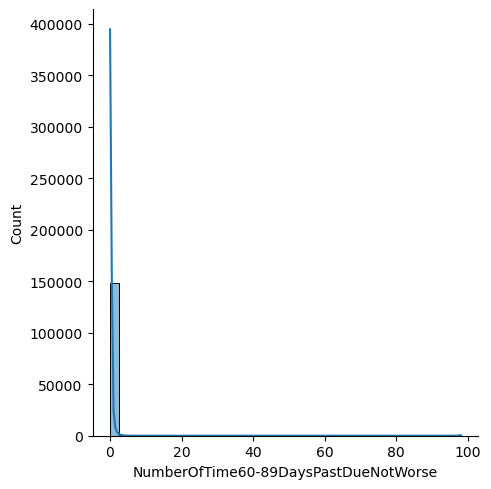

In [44]:
sns.displot(df["NumberOfTime60-89DaysPastDueNotWorse"],bins = 40,kde = True)
plt.show()

# Observation :

- Zero-inflated distribution.
- Most values = 0.
- Few high counts

# Meaning:
- Most customers have clean history.
- Few chronic defaulters exist.
- Flag + bucket approach is justified.

# Bivariate analysis

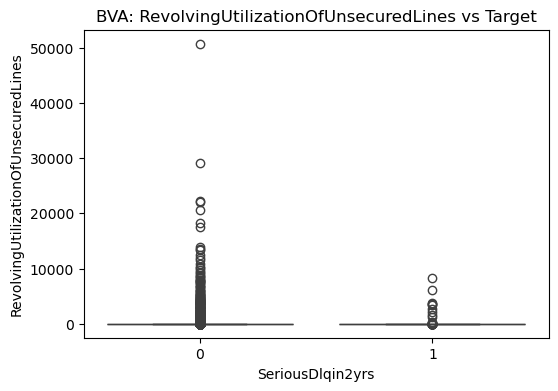

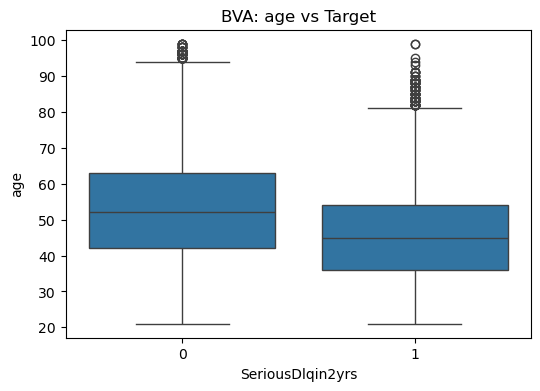

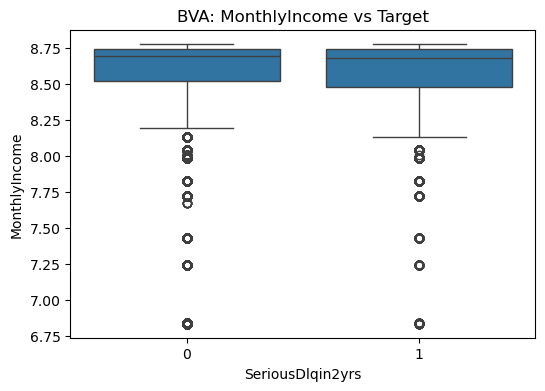

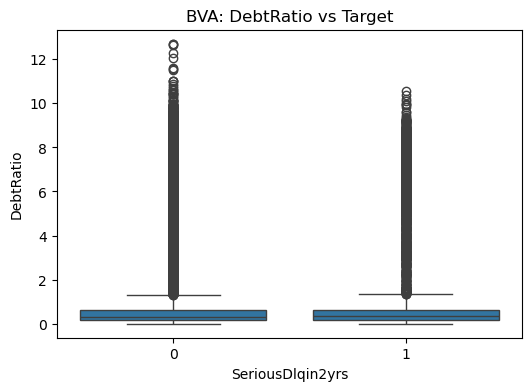

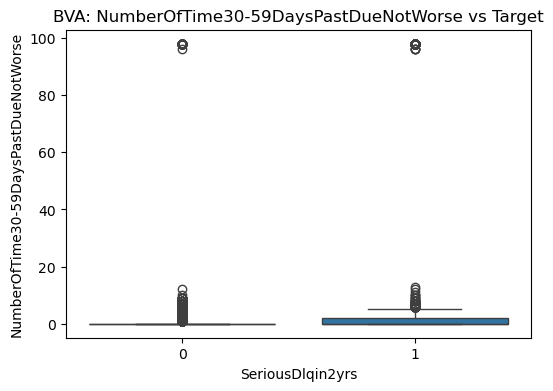

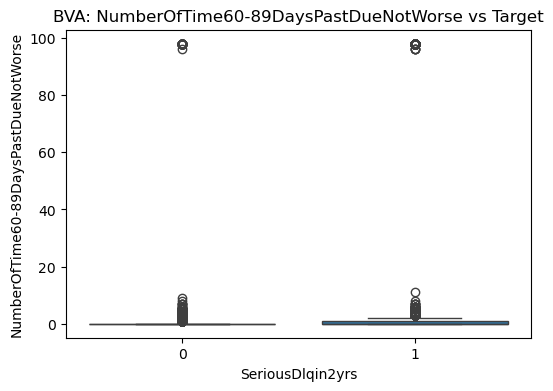

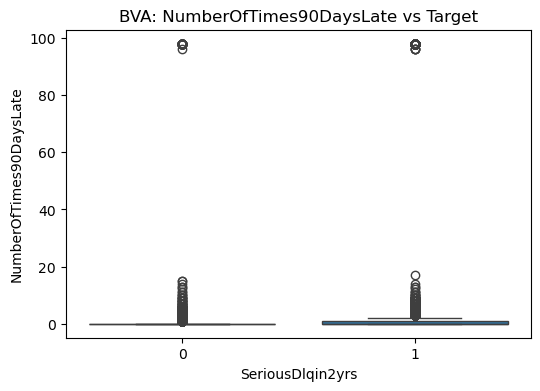

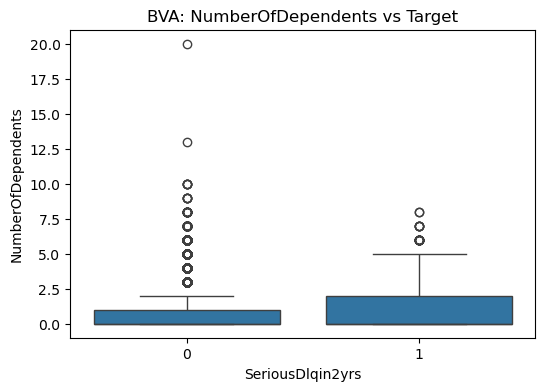

In [45]:
target = 'SeriousDlqin2yrs'

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[target],y=df[col])
    plt.title(f'BVA: {col} vs Target')
    plt.show()

# Observation : 

## Age vs Default : 
Observation : 
- Defaulters are younger on average.
- Older customers default less.

Meaning
- Age is negatively correlated with risk.
- Younger → unstable income → higher risk.
  
## MonthlyIncome vs Default
Observation
- Defaulters cluster at low income.
- High-income group rarely defaults.

Meaning
- Income is protective factor.
- Log income is strong feature.

## DebtRatio vs Default
Observation
- Defaulters have higher debt ratios.
- Non-defaulters concentrated at low values.

Meaning
- Over-leverage = high default probability.
- One of the strongest predictors.
  
## Utilization vs Default
Observation
Defaulters show higher utilization.
High-risk bucket dominates defaulters.

Meaning
- Maxed-out credit = stress signal.
- Buckets are meaningful.

## Delinquency vs Default
Observation
Almost all high delinquency values = defaulters.
Zero group has low default.

Meaning
- Past behavior predicts future behavior.
- Strongest feature in dataset.


# Data Validation

In [164]:
df.isna().sum()

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
Income_missing                          0
dep_missing                             0
raw_income                              0
income_zero_flag                        0
raw_debt                                0
Credit_Utilization                      0
dtype: int64

In [165]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing,raw_income,income_zero_flag,raw_debt
count,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,149986.000000,1.499860e+05,149986.000000,149986.000000
mean,75000.499467,0.066840,6.048985,52.291101,0.421053,1.525082,5474.318793,8.452922,0.265998,1.018295,0.240409,0.742609,0.198178,0.026142,6.429065e+03,0.010894,353.002995
std,43301.645266,0.249745,249.767020,14.764163,4.192973,2.627182,1055.660796,5.146013,4.169498,1.129787,4.155373,1.105932,0.398629,0.159559,1.289853e+04,0.103806,2037.902441
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,927.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,37500.250000,0.000000,0.029878,41.000000,0.000000,0.161332,5000.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.774000e+03,0.000000,0.175075
50%,75000.500000,0.000000,0.154234,52.000000,0.000000,0.312255,5948.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.584000e+03,0.000000,0.366503
75%,112500.750000,0.000000,0.559053,63.000000,0.000000,0.624922,6250.000000,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,7.400000e+03,0.000000,0.868100
max,150000.000000,1.000000,50708.000000,99.000000,98.000000,12.705832,6500.000000,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000,1.000000,3.008750e+06,1.000000,329664.000000


## Conclusion

- Data cleaned with domain logic
- Outliers treated using log and capping
- Key risk indicators engineered
- Dataset ready for modeling

In [166]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_missing,dep_missing,raw_income,income_zero_flag,raw_debt,Credit_Utilization
0,1,1,0.766127,45,2,0.589442,6100.0,13,0,6,0,2.0,0,0,9120.0,0,0.802982,Risk
1,2,0,0.957151,40,0,0.115002,5464.0,4,0,0,0,1.0,0,0,2600.0,0,0.121876,Risk
2,3,0,0.658180,38,1,0.081684,5250.0,2,1,0,0,0.0,0,0,3042.0,0,0.085113,Medium
3,4,0,0.233810,30,0,0.035415,3622.5,5,0,0,0,0.0,0,0,3300.0,0,0.036050,Good
4,5,0,0.907239,49,1,0.024620,6390.0,7,0,1,0,0.0,0,0,63588.0,0,0.024926,Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.203048,4700.0,4,0,1,0,0.0,0,0,2100.0,0,0.225131,Good
149996,149997,0,0.299745,44,0,0.540324,6000.0,4,0,1,0,2.0,0,0,5584.0,0,0.716562,Good
149997,149998,0,0.246044,58,0,8.261268,6340.0,18,0,1,0,0.0,1,0,6340.0,0,3870.000000,Good
149998,149999,0,0.000000,30,0,0.000000,3622.5,4,0,0,0,0.0,0,0,5716.0,0,0.000000,Good
